# 1. Business Description
Introduction — Hotel Booking Demand Analysis

This project analyzes hotel booking demand and how reservation outcomes are influenced by key variables specific to the hospitality industry, such as customer type, length of stay, booking lead time, room type, seasonality, and distribution channels.

A central variable in the dataset is is_canceled, which indicates whether a reservation was ultimately canceled. This variable is critical both for exploratory analysis and for building predictive models, as cancellation behavior has direct operational and financial implications for hotels, including revenue management, occupancy forecasting, and overbooking strategies.

Beyond descriptive analysis, the project investigates structural patterns in booking behavior across different hotel types, months, and customer segments, aiming to identify relationships between pricing (adr), seasonality, and cancellation likelihood.

For the predictive component, several baseline machine learning models will be implemented alongside more advanced ensemble methods and embedding-based representations of categorical features. The objective is to evaluate how different modeling approaches perform on this dataset and to understand which techniques are more suitable for capturing the nonlinear and heterogeneous patterns typical of hotel booking data.

The overall goal is twofold:

To provide analytical insight into the factors that drive booking and cancellation behavior.
To develop predictive models that can assist in forecasting cancellation risk and supporting data-driven decision-making in hotel demand management.

# 2. Importing libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression ,RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,StackingClassifier, ExtraTreesClassifier,AdaBoostClassifier,BaggingClassifier,VotingClassifier

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier



### Data source from https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

In [2]:
#Load data
df=pd.read_csv("/kaggle/input/hotel-booking-demand/hotel_bookings.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


# 3. Data Analysis

In [3]:
# Delete the duplicated rows
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")

df.drop_duplicates(inplace=True)
df.shape

Duplicates found: 31994


(87396, 32)

In [4]:
# search for unique values
summary = pd.DataFrame({
    'Unique Values': df.nunique()
})

summary

,Unique Values
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [5]:
# Chech for null & missing 
# only numerical values 

print("✔ Success") 
print("✘ Further investigation") 
# print("? Further investigation")

summary = pd.DataFrame({
    'Non-Null Count': df.notna().sum(),
    'Non-Null (%)': (df.notna().mean() * 100).round(2),
    'Missing Count': df.isna().sum(),
    'Missing (%)': (df.isna().mean() * 100).round(2),
    'Data Type': df.dtypes
})

summary['Result'] = np.where(
    (summary['Missing (%)'] == 0) & (summary['Data Type'] == 'int64'),
    "✔",
    "✘"
)

summary

✔ Success
✘ Further investigation


,Non-Null Count,Non-Null (%),Missing Count,Missing (%),Data Type,Result
hotel,87396,100.00,0,0.00,object,✘
is_canceled,87396,100.00,0,0.00,int64,✔
lead_time,87396,100.00,0,0.00,int64,✔
arrival_date_year,87396,100.00,0,0.00,int64,✔
arrival_date_month,87396,100.00,0,0.00,object,✘
arrival_date_week_number,87396,100.00,0,0.00,int64,✔
arrival_date_day_of_month,87396,100.00,0,0.00,int64,✔
stays_in_weekend_nights,87396,100.00,0,0.00,int64,✔
stays_in_week_nights,87396,100.00,0,0.00,int64,✔
adults,87396,100.00,0,0.00,int64,✔


### ⚠️ Important step — column removed 

In [6]:
### The "company" column has more than 90% missing data and will be deleted
df.drop(columns=['company'], inplace=True)

In [7]:
for col in df.columns:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("-" * 20)

Unique values in column 'hotel':
['Resort Hotel' 'City Hotel']
--------------------
Unique values in column 'is_canceled':
[0 1]
--------------------
Unique values in column 'lead_time':
[342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 1

# 4. Transforming Data

In [8]:
# 1. Remove leading and trailing spaces from single words
# cases like " name " or "age " or " customer "
df.columns = df.columns.str.strip()

# 2. Replace spaces between words with underscores
# cases like "arrival date" → "arrival_date"
df.columns = df.columns.str.replace(' ', '_')

### The nan values from children will be filled with 0
### The nan values from agent will be filled with 0


In [9]:
#df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
#df['agent'] = df['agent'].fillna(0)


In [10]:
# adults, babies and children cant be zero at same time, so dropping the rows having all these zero at same time
filter = (df.children == 0) & (df.adults == 0) & (df.babies == 0)
df[filter]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,1,No Deposit,NaN,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,0,No Deposit,NaN,0,Transient,0.00,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,0,No Deposit,38.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,1,No Deposit,308.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,1,No Deposit,308.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,...,1,No Deposit,7.0,0,Transient,100.80,0,0,Check-Out,2017-06-30
115091,City Hotel,0,1,2017,June,26,30,0,1,0,...,0,No Deposit,NaN,0,Transient,0.00,1,1,Check-Out,2017-07-01
116251,City Hotel,0,44,2017,July,28,15,1,1,0,...,2,No Deposit,425.0,0,Transient,73.80,0,0,Check-Out,2017-07-17
116534,City Hotel,0,2,2017,July,28,15,2,5,0,...,1,No Deposit,9.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


### Cleaning columns with zero customers

In [11]:
df.drop(df[filter].index, inplace=True)
df.shape

(87230, 31)

In [12]:
# Let's check the ballance in data source between canceled and fulfilled
is_can = len(df[df['is_canceled']==1])
print("Percentage cancelation %= ", is_can/len(df)*100)
df['reservation_status'].value_counts(normalize=True)*100

Percentage cancelation %=  27.523787687722113


reservation_status
Check-Out    72.476212
Canceled     26.362490
No-Show       1.161298
Name: proportion, dtype: float64

### There are unbalanced data, that could be taken in consideration for choosing the right Scaler and Metric
### A value of is_canceled = 1 represents the aggregation of both Canceled and No-Show outcomes from the reservation_status variable. Consequently, the reservation_status column becomes redundant, as its informational content is fully captured by the is_canceled indicator.


### ⚠️ Important step — column removed 

In [13]:
df.drop(columns=['reservation_status'], inplace=True)

# 5. Exploratory Data Analysis (EDA)

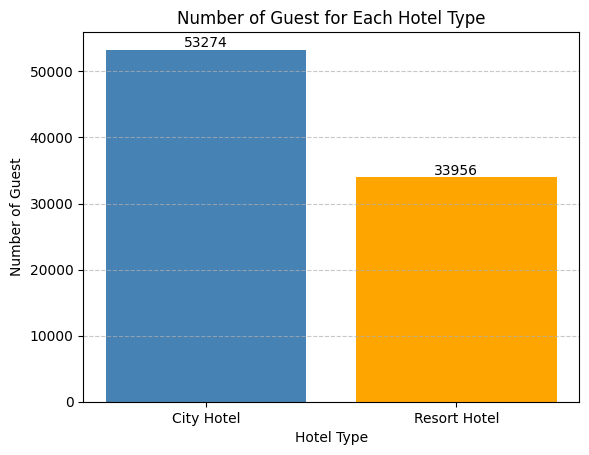

In [14]:
# There are 2 hotels. Let's see the number of guest in each hotels
counts = df['hotel'].value_counts()

colors = ['steelblue', 'orange']  # două culori distincte

bars = plt.bar(counts.index, counts.values, color=colors)

plt.xlabel('Hotel Type')
plt.ylabel('Number of Guest')
plt.title('Number of Guest for Each Hotel Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.show()

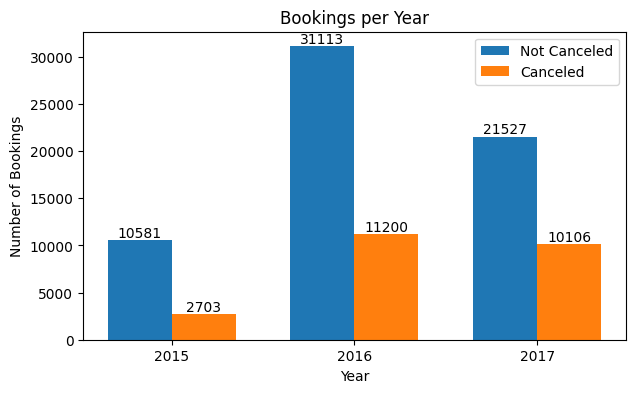

In [15]:
# Let's see the Bookings  / year for each hotel in relation with cancellations
counts = df.groupby(['arrival_date_year', 'is_canceled']).size().unstack()
counts = counts.reindex(columns=[0, 1], fill_value=0)

x = np.arange(len(counts.index))
width = 0.35

plt.figure(figsize=(7,4))

bars1 = plt.bar(x - width/2, counts[0], width, label='Not Canceled')
bars2 = plt.bar(x + width/2, counts[1], width, label='Canceled')

# valori deasupra barelor
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xticks(x, counts.index)

plt.title('Bookings per Year')
plt.xlabel('Year')
plt.ylabel('Number of Bookings')

plt.legend()

plt.show()

### Let's check the relation between country and is_canceled

In [16]:
# Contingence table
ct = pd.crosstab(df['country'], df['is_canceled'])
ct.head()

is_canceled,0,1
country,,
ABW,2,0
AGO,149,193
AIA,1,0
ALB,9,2
AND,2,5


In [17]:
# Chi-Square test
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 3415.597005832502
p-value: 0.0


In [18]:
import numpy as np

n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print("Cramer's V:", cramers_v)

Cramer's V: 0.1978793047731594


| V       | Forță relație |
| ------- | ------------- |
| < 0.1   | foarte slabă  |
| 0.1–0.3 | slabă         |
| 0.3–0.5 | moderată      |
| > 0.5   | puternică     |


### p < 0.05 → există relație statistic semnificativă între țară și anulări
### p ≥ 0.05 → nu există relație semnificativă

### The Chi-Square test indicates a statistically significant relationship between country and cancellation behavior (p ≈ 0). However, the effect size measured by Cramér’s V (0.195) suggests a weak to moderate association, indicating that while country contributes to cancellation patterns, it is not a dominant predictive factor.

In [19]:
# Distribution of guests per country
country_wise_counts = (
    df.loc[df['is_canceled'] == 0, 'country']
      .value_counts()
      .reset_index()
)

country_wise_counts.columns = ['country', 'No of guests']
country_wise_counts

,country,No of guests
0,PRT,17573
1,GBR,8440
2,FRA,7091
3,ESP,5382
4,DEU,4332
...,...,...
161,KIR,1
162,ATF,1
163,TJK,1
164,SLE,1


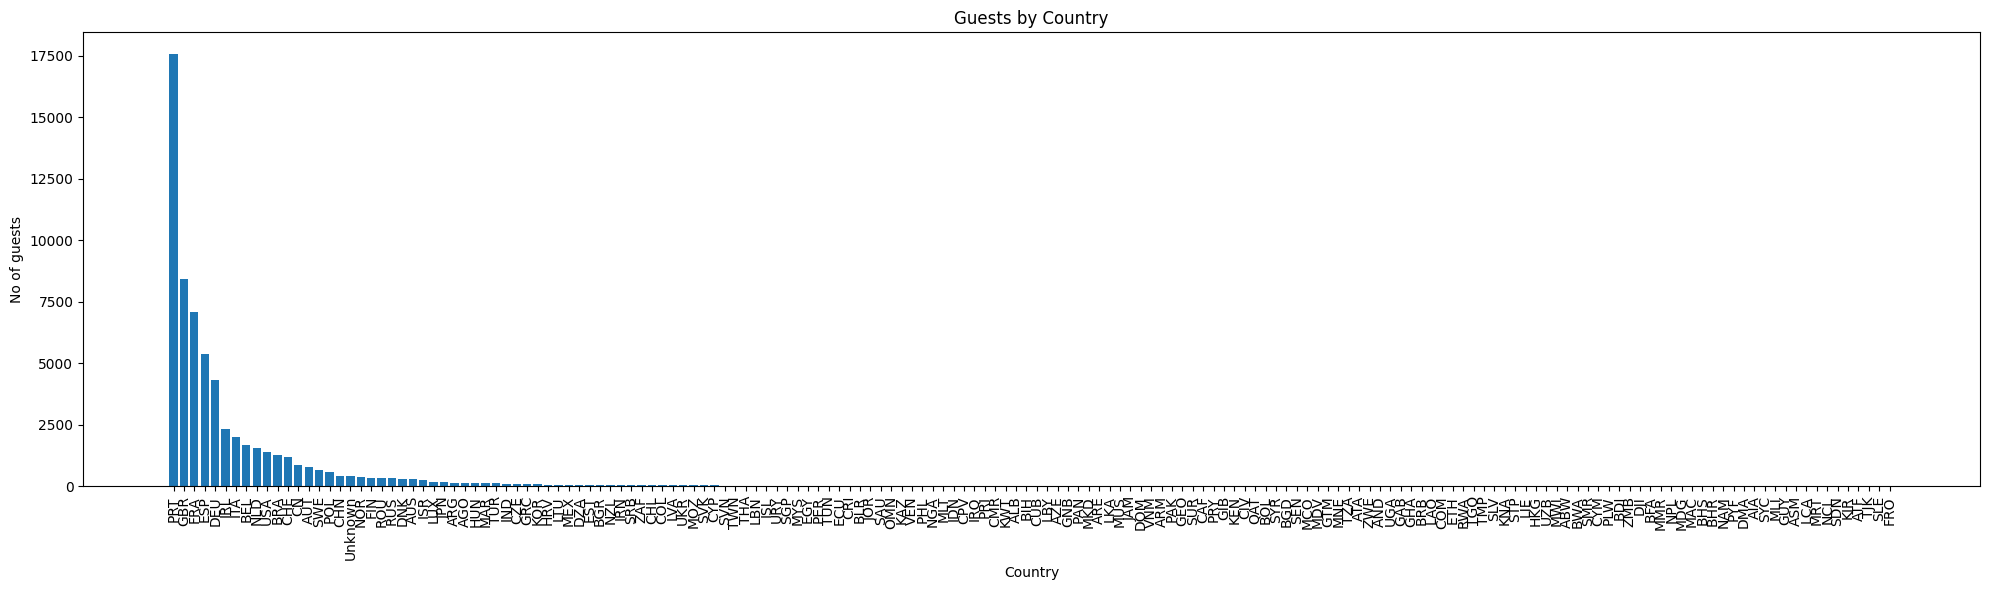

In [20]:
# visualising distribution of guests per country
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(country_wise_counts['country'], country_wise_counts['No of guests'])
ax.set_title('Guests by Country')
ax.set_xlabel('Country')
ax.set_ylabel('No of guests')
plt.xticks(rotation=90)
plt.tight_layout()

### There are clients from all over the world, across 165 countries.
### Most guests are from Portugal and other countries in Europe.

### * Visualise the tipe of reserved room by hotel

In [21]:
dfx = df[df['is_canceled'] == 0]
fig= px.box(
    data_frame = df.loc[df['is_canceled'] == 0],
    x = 'reserved_room_type',
    y = 'adr',
    color = 'hotel',
    template = 'plotly_white'
)
fig.show()

### The box plot shows the distribution of adr (average daily rate) for each reserved room type, compared across hotel types, highlighting the median, variability, and outliers.

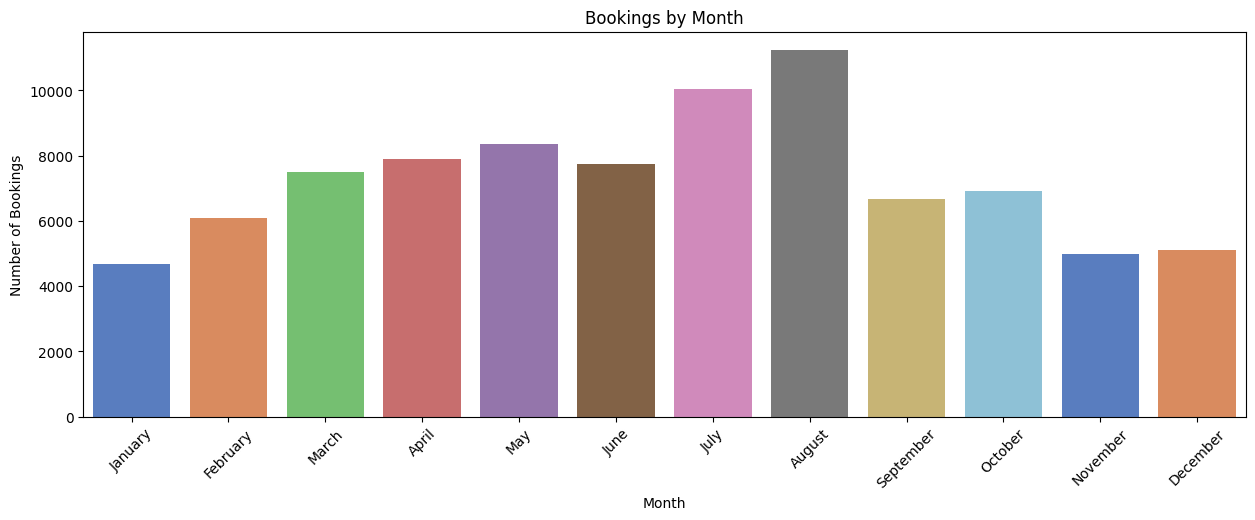

In [22]:
# Total bookings per month
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

top_months = df["arrival_date_month"].value_counts().reindex(month_order)

plt.figure(figsize=(15,5))

sns.barplot(
    x=top_months.index,
    y=top_months.values,
    hue=top_months.index,
    palette='muted',
    legend=False
)

plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)
plt.show()

### Top booking months: August, July, May → peak summer vacation season¶
### Least bookings: November, February → off-season periods

### Shows clear seasonal booking trends in hotels

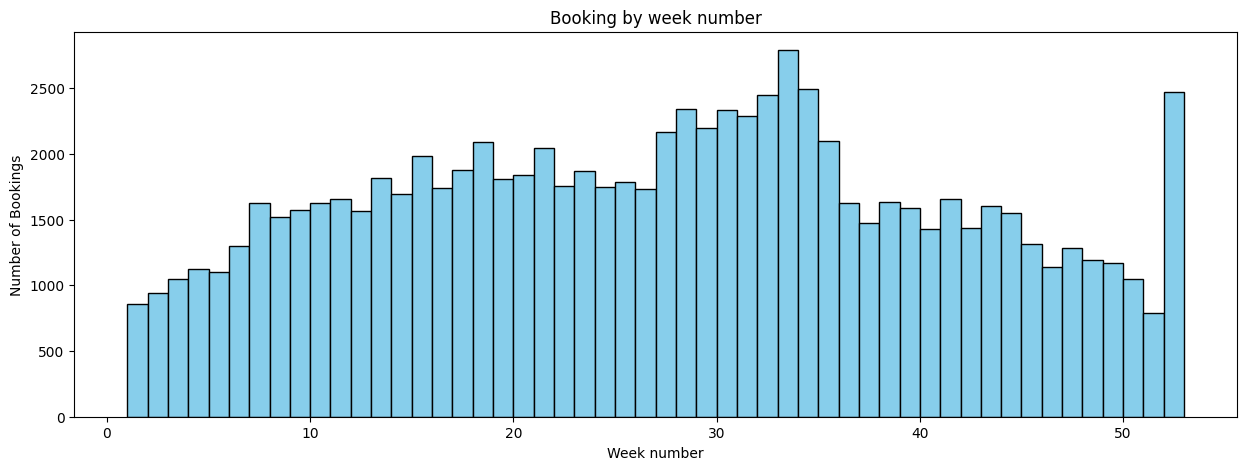

In [23]:
# Histograma
plt.figure(figsize=(15,5))
plt.hist(df['arrival_date_week_number'], bins=52, color='skyblue', edgecolor='black')  # bins = numărul de "cutii"
plt.xlabel('Week number')
plt.ylabel('Number of Bookings')
plt.title('Booking by week number')
plt.show()

### Analyse parameter adr by resort_hotel and city_hotel and investigate the connection between is_cancel and price (adr)

In [24]:
resort_hotel = (
    df.loc[df['hotel'] == 'Resort Hotel']
      .groupby('arrival_date_month')
      .agg(
          mean_adr=('adr', 'mean'),
          cancellations=('is_canceled', 'sum'),
          total_bookings=('is_canceled', 'size')
      )
      .reset_index()
)

resort_hotel['cancellation_rate_%'] = (
    resort_hotel['cancellations'] / resort_hotel['total_bookings'] * 100
)

resort_hotel['arrival_date_month'] = pd.Categorical(
    resort_hotel['arrival_date_month'],
    categories=month_order,
    ordered=True
)

resort_hotel = resort_hotel.sort_values('arrival_date_month').reset_index(drop=True)

resort_hotel

,arrival_date_month,mean_adr,cancellations,total_bookings,cancellation_rate_%
0,January,49.181693,274,1961,13.972463
1,February,54.102809,439,2492,17.616372
2,March,57.590889,465,2656,17.507530
3,April,79.283805,659,2828,23.302687
4,May,80.551101,696,2942,23.657376
5,June,112.380859,833,2759,30.192099
6,July,156.166914,1300,4313,30.141433
7,August,187.566659,1513,4666,32.426061
8,September,100.892331,575,2450,23.469388
9,October,63.723065,515,2724,18.906021


In [25]:
city_hotel = (
    df.loc[df['hotel'] == 'City Hotel']
      .groupby('arrival_date_month')
      .agg(
          mean_adr=('adr', 'mean'),
          cancellations=('is_canceled', 'sum'),
          total_bookings=('is_canceled', 'size')
      )
      .reset_index()
)

city_hotel['cancellation_rate_%'] = (
    city_hotel['cancellations'] / city_hotel['total_bookings'] * 100
)

city_hotel['arrival_date_month'] = pd.Categorical(
    city_hotel['arrival_date_month'],
    categories=month_order,
    ordered=True
)

city_hotel = city_hotel.sort_values('arrival_date_month').reset_index(drop=True)

city_hotel

,arrival_date_month,mean_adr,cancellations,total_bookings,cancellation_rate_%
0,January,85.269875,763,2724,28.010279
1,February,89.266427,973,3591,27.095517
2,March,95.193911,1364,4833,28.222636
3,April,117.314134,1747,5072,34.444006
4,May,128.055724,1746,5402,32.321362
5,June,123.996416,1520,4997,30.418251
6,July,120.318314,1896,5730,33.089005
7,August,125.148662,2109,6576,32.071168
8,September,118.764693,1066,4232,25.189036
9,October,107.585401,1127,4197,26.852514


In [26]:
final = resort_hotel.merge(
    city_hotel,
    on='arrival_date_month',
    suffixes=('_resort', '_city')
)

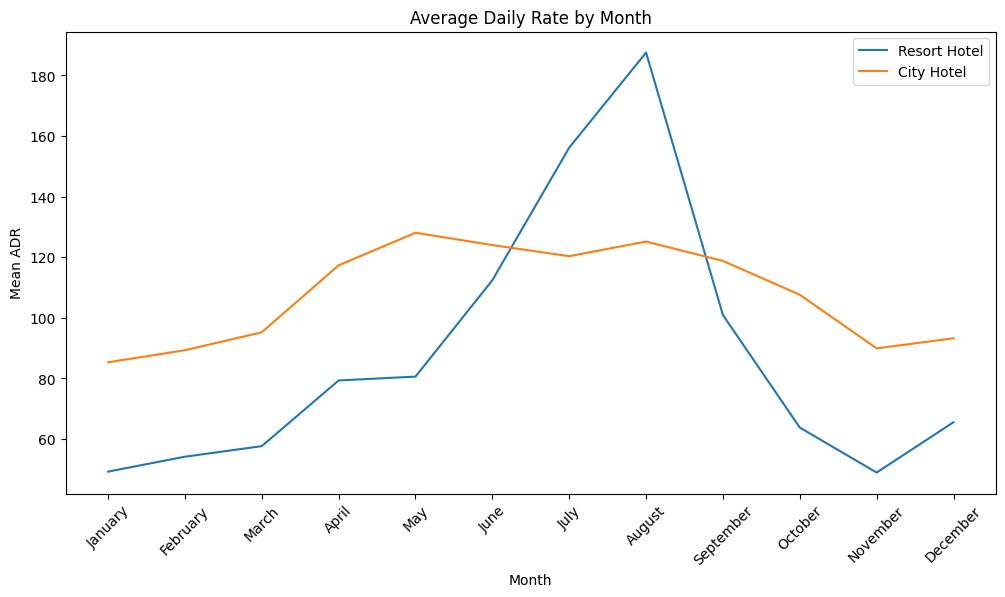

In [27]:
plt.figure(figsize=(12,6))

plt.plot(final['arrival_date_month'], final['mean_adr_resort'])
plt.plot(final['arrival_date_month'], final['mean_adr_city'])

plt.title('Average Daily Rate by Month')
plt.xlabel('Month')
plt.ylabel('Mean ADR')
plt.xticks(rotation=45)
plt.legend(['Resort Hotel', 'City Hotel'])
plt.show()

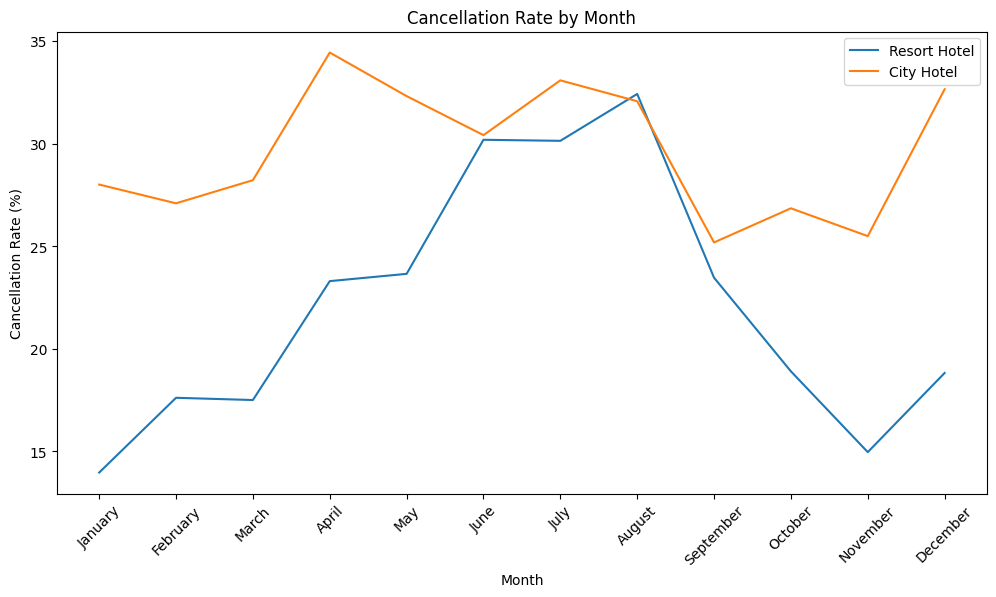

In [28]:
plt.figure(figsize=(12,6))

plt.plot(final['arrival_date_month'], final['cancellation_rate_%_resort'])
plt.plot(final['arrival_date_month'], final['cancellation_rate_%_city'])

plt.title('Cancellation Rate by Month')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.legend(['Resort Hotel', 'City Hotel'])
plt.show()

### Resort_Hotel- expensive in augest month  //  
### City_Hotel- expensive in may month
### There is a visible connection between booking price and cancelation


### Let's analyse the number of stays related to number of nights

In [29]:
df2 = df[df["is_canceled"] == 0].copy()
df2.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,NaN,0,Transient,0.0,0,0,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,NaN,0,Transient,0.0,0,0,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,NaN,0,Transient,75.0,0,0,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,0,Transient,75.0,0,0,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,0,Transient,98.0,0,1,2015-07-03


In [30]:
df2['total_night']=df2['stays_in_weekend_nights']+df2['stays_in_week_nights']
df2

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,total_night
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,NaN,0,Transient,0.00,0,0,2015-07-01,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,NaN,0,Transient,0.00,0,0,2015-07-01,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,NaN,0,Transient,75.00,0,0,2015-07-02,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.00,0,0,2015-07-02,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,2015-07-03,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,No Deposit,394.0,0,Transient,96.14,0,0,2017-09-06,7
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,No Deposit,9.0,0,Transient,225.43,0,2,2017-09-07,7
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,No Deposit,9.0,0,Transient,157.71,0,4,2017-09-07,7
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,No Deposit,89.0,0,Transient,104.40,0,0,2017-09-07,7


In [31]:
stay = df2.groupby(['total_night', 'hotel']).agg('count').reset_index()
stay = stay.iloc[:, :3]
stay = stay.rename(columns={'is_canceled':'Number of stays'})
stay

,total_night,hotel,Number of stays
0,0,City Hotel,218
1,0,Resort Hotel,350
2,1,City Hotel,7972
3,1,Resort Hotel,6036
4,2,City Hotel,7630
...,...,...,...
57,46,Resort Hotel,1
58,48,City Hotel,1
59,56,Resort Hotel,1
60,60,Resort Hotel,1


In [32]:
# Looks like are guests with 0 nights in hotel
df2[df2['total_night'] == 0][
    ['adults','children','babies','meal','market_segment','customer_type']
].head(20)

,adults,children,babies,meal,market_segment,customer_type
0,2,0.0,0,BB,Direct,Transient
1,2,0.0,0,BB,Direct,Transient
167,2,0.0,0,BB,Online TA,Transient
168,1,0.0,0,BB,Direct,Transient
196,2,0.0,0,BB,Direct,Transient
197,2,0.0,0,BB,Online TA,Transient
459,2,0.0,0,BB,Online TA,Transient
568,1,0.0,0,BB,Offline TA/TO,Transient
569,2,0.0,0,BB,Online TA,Transient
618,2,2.0,0,BB,Online TA,Transient


In [33]:
px.bar(data_frame = stay, x = 'total_night', y = 'Number of stays', color = 'hotel', barmode = 'group',
        template = 'plotly_dark')

<Axes: xlabel='market_segment', ylabel='stays_in_weekend_nights'>

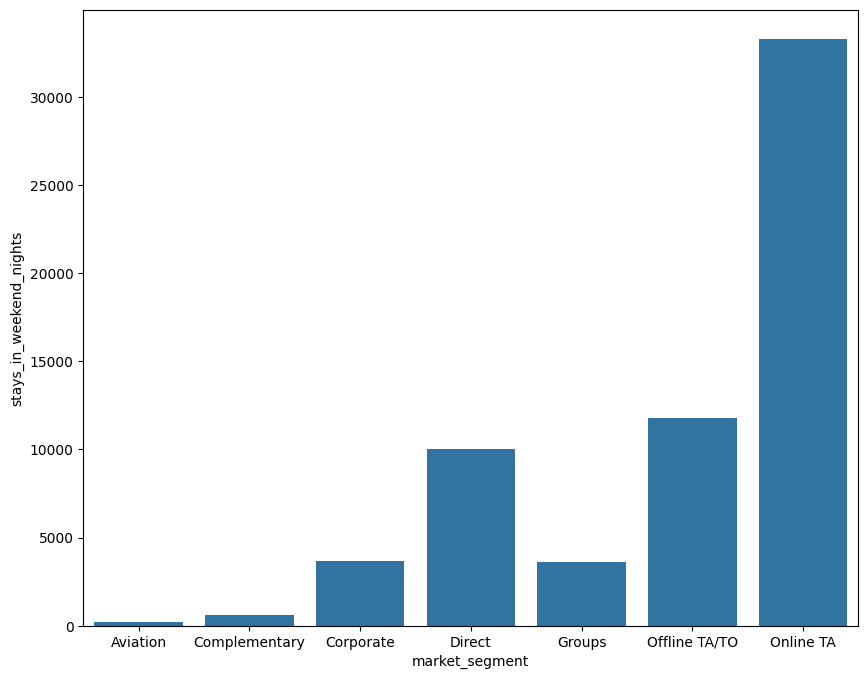

In [34]:
plt.figure(figsize=(10,8))
sns.barplot(x=df[df['is_canceled']==0].groupby('market_segment')['stays_in_weekend_nights'].count().index,
            y=df[df['is_canceled']==0].groupby('market_segment')['stays_in_weekend_nights'].count())

In [35]:
# is family or not - has different pattern for cancelation
df['total_guests'] = df[['adults','children','babies']].sum(axis=1)
df['is_family'] = (df['children'] + df['babies'] > 0).astype(int)


# 6. Data Preprocessing

### Drop uneeded columns

In [36]:
cols_to_drop = [
    'adults',
    'children',
    'babies',
    'reservation_status_date',
    'agent',
    'arrival_date_day_of_month',
    'arrival_date_week_number',
    'assigned_room_type',
    'booking_changes',
    'days_in_waiting_list',
    'deposit_type',
    'adr'
]

df.drop(columns=cols_to_drop, inplace=True)
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
       'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'customer_type',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'is_family'],
      dtype='object')

### Data_encoding

### Data split

In [37]:
x = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [38]:
categorical_cols = [
    'hotel',
    'arrival_date_month',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'customer_type' ,
    'country'
]

numerical_cols = [col for col in x.columns if col not in categorical_cols]

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", RobustScaler(), numerical_cols)
    ]
)

In [40]:
preprocessor.fit(x_train)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['hotel', 'arrival_date_month', 'meal',
                                  'market_segment', 'distribution_channel',
                                  'reserved_room_type', 'customer_type',
                                  'country']),
                                ('num', RobustScaler(),
                                 ['lead_time', 'arrival_date_year',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous_bookings_not_canceled',
                                  'required_car_parking_spaces',
                                  'total_of_special_requests', 'total_guests',
                                  'is_family'])])

In [41]:
from imblearn.pipeline import Pipeline

# pipeline
# RobustSscaler for asymmetrical data
# Let's test some different classification models
models = {
    "DecisionTree": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))
    ]),
    "ExtraTrees": Pipeline([
        ("prep", preprocessor),
        ("model", ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42))
    ]),
    "AdaBoost": Pipeline([
        ("prep", preprocessor),
        ("model", AdaBoostClassifier(random_state=42))
    ]),
    "Bagging": Pipeline([
        ("prep", preprocessor),
        ("model", BaggingClassifier(random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42
        ))
    ]),
    "LightGBM": Pipeline([
        ("prep", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=50,
            min_child_samples=20,
            bagging_fraction=0.8,
            feature_fraction=0.8,
            bagging_freq=1,
            scale_pos_weight=2.6,
            random_state=42
        ))
    ]),
    "CatBoost": Pipeline([
        ("prep", preprocessor),
        ("model", CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            verbose=0,
            random_state=42
        ))
    ])
}

# 7. Training & Evaluation

In [42]:
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_probs):
    thresholds = np.arange(0.2, 0.8, 0.05)
    best_t, best_f1 = 0, 0
    
    for t in thresholds:
        y_pred = (y_probs > t).astype(int)
        f1 = f1_score(y_true, y_pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
            
    return best_t, best_f1

In [43]:
%%time

from sklearn.metrics import accuracy_score, f1_score, classification_report

results = []
reports = {}

for name, model in models.items():
    print(name)
    model.fit(x_train, y_train)
    
    # probabilități
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(x_test)[:,1]
        best_t, best_f1 = find_best_threshold(y_test, y_probs)
        y_pred = (y_probs > best_t).astype(int)
    else:
        y_pred = model.predict(x_test)  # fallback (ex: SVC fără probability=True)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })
    
    reports[name] = classification_report(y_test, y_pred)

DecisionTree
RandomForest
ExtraTrees
AdaBoost
Bagging
XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:32:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




LightGBM
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 19207, number of negative: 50577
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=tru

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
CatBoost
CPU times: user 18min 13s, sys: 4.12 s, total: 18min 17s
Wall time: 5min 7s


### Rezults Comparation

In [44]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,F1 Score
6,LightGBM,0.818698,0.707265
5,XGBoost,0.819099,0.701814
7,CatBoost,0.816004,0.695446
1,RandomForest,0.815316,0.693843
4,Bagging,0.795483,0.670849
2,ExtraTrees,0.784707,0.664643
3,AdaBoost,0.754500,0.625383
0,DecisionTree,0.779376,0.606723


### Model Saving

In [45]:
import joblib

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(x_train, y_train)
joblib.dump(best_model, "/kaggle/working/best_model.pkl")

[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 19207, number of negative: 50577
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Ligh

['/kaggle/working/best_model.pkl']

# 8. Detailed report

In [46]:
for name in reports:
    print(f"\n{name}")
    print(reports[name])


DecisionTree
              precision    recall  f1-score   support

           0       0.85      0.84      0.85     12644
           1       0.60      0.62      0.61      4802

    accuracy                           0.78     17446
   macro avg       0.72      0.73      0.73     17446
weighted avg       0.78      0.78      0.78     17446


RandomForest
              precision    recall  f1-score   support

           0       0.90      0.84      0.87     12644
           1       0.64      0.76      0.69      4802

    accuracy                           0.82     17446
   macro avg       0.77      0.80      0.78     17446
weighted avg       0.83      0.82      0.82     17446


ExtraTrees
              precision    recall  f1-score   support

           0       0.90      0.79      0.84     12644
           1       0.58      0.78      0.66      4802

    accuracy                           0.78     17446
   macro avg       0.74      0.78      0.75     17446
weighted avg       0.81      0.78 

### Model performance heatmap

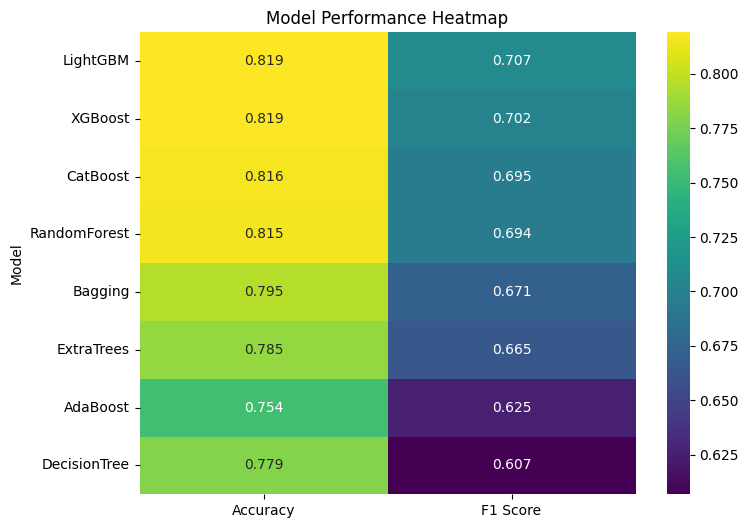

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(results_df.set_index("Model"), annot=True, fmt=".3f", cmap="viridis")
plt.title("Model Performance Heatmap")
plt.show()  


# 9. Conclusion and Insight – Hotel Booking Cancellation Prediction 📊🏨

The comparative analysis of classification models highlights the superior performance of ensemble-based algorithms, particularly the Random Forest model, which achieves high F1 scores for both majority and minority classes. Similar results are observed for Extra Trees and Bagging models, confirming the robustness of tree-based ensemble methods.

A key insight derived from the results is the non-linear nature of the dataset. Linear models, such as Logistic Regression and Ridge Classifier, show significantly lower performance, indicating that the relationships between variables are complex and involve interactions that cannot be effectively captured by simple linear approaches.

Although boosting models (CatBoost, XGBoost, LightGBM) deliver competitive results, they achieve slightly better F1 scores for the minority class (cancellations) than Random Forest, highlighting their ability to capture more subtle patterns. However, the overall performance across models is largely dominated by tree-based ensemble approaches.

An important aspect of this dataset is class imbalance, as cancellations (minority class) are significantly less frequent than non-cancellations (majority class). This imbalance affects metrics such as recall and F1 for the minority class and should be investigated further in future work, potentially with resampling techniques, class weighting, or advanced imbalance-aware algorithms.

In conclusion, for the task of predicting booking cancellations, tree-based ensemble models—particularly Random Forest, LightGBM, and XGBoost—represent the most effective choice, offering a strong balance between performance, stability, interpretability, and handling of class imbalance.